# Demonstration: weed control and Parrondo-type reversals

This notebook extends Ray's original simulator walkthrough. Read the explanation before each code cell; use **Restart Kernel and Run All** to reproduce outputs.

**Presentation route (10 minutes):** simulator and animation → Baseline/A/B/AB → search and margin → BA/block/random → brief mechanism check. Detailed sensitivity and random controls are supporting material for questions.

The existing data, grid and animation sections are retained below. Their settings now match the report: **1 km cells**, population coefficient **0.000783**, **100 abstract steps**. The index is a model quantity, not observed weed abundance. Figures A1 and A2 are saved by this notebook for direct use in the report.

# Set Working Directory to Project Root

All modules in this project use absolute imports. Therefore, the working directory is set to the project root to ensure that all module references can be resolved correctly.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os

repo_root = Path.cwd().resolve()
os.chdir(repo_root)

print(Path.cwd())

C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


# Load Geo Data

The locality polygons have been preprocessed and integrated with population density data. The resulting GeoDataFrame contains both spatial geometry and population-related attributes required for model initialisation.

## Data Sources

- **Population Data:** [Australian Bureau of Statistics (ABS)](https://www.abs.gov.au/statistics/people/population/population-census/latest-release)
- **Locality Polygons:** [WA Localities](https://catalogue.data.wa.gov.au/dataset/localities)

In [2]:
from utils.data_loader import load_locality_data

localities = load_locality_data()

metro = localities[
    localities["postcode"].astype(int).between(6000,6199)
].copy()

C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\utils\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


# Convert Geo Data to Weed Index Data

The initial Weed Index is calculated from population density using an exponential decay function. The resulting Weed Index is then assigned to the corresponding spatial units for subsequent grid generation and simulation.

In [3]:
import utils.weed_simulation_tools as wst

metro['weed_index'] = wst.weed_index_initialize(density=metro['population_density_km2'],
                                            pressure_coef=0.000783,
                                            w_min=0.05,
                                            w_max=1)

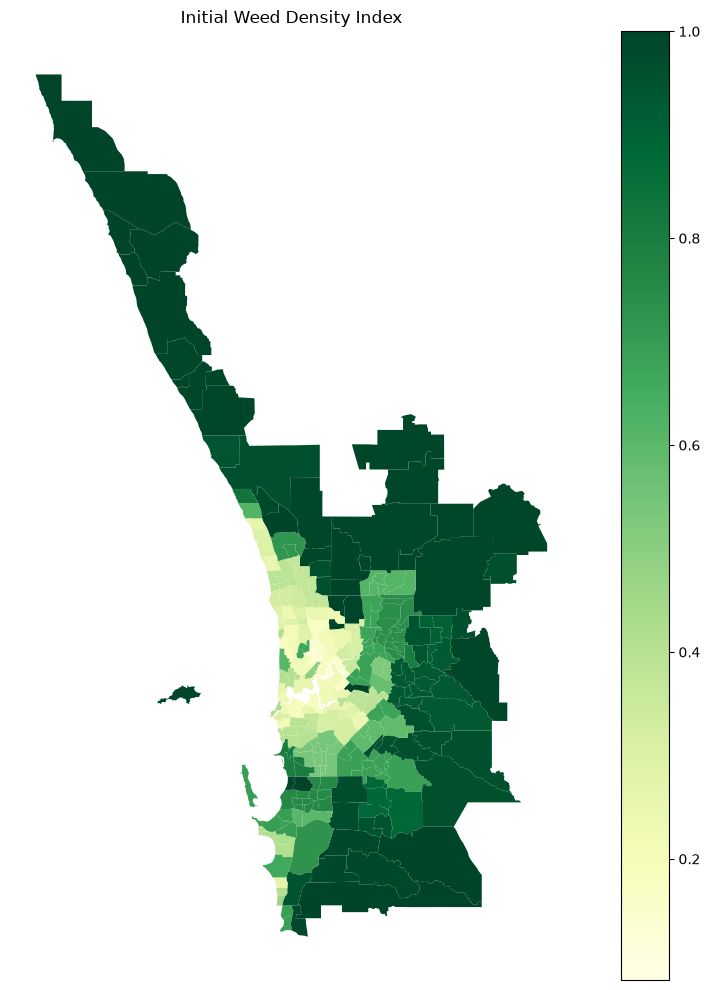

In [4]:
# Check the convertion result
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

metro.plot(
    column="weed_index",
    cmap="YlGn",
    legend=True,
    ax=ax,
    edgecolor="none"
)

ax.set_title("Initial Weed Density Index")
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Polygon-to-Grid Conversion

The polygon-to-grid conversion is encapsulated in the `polygon_to_grid()` function, which provides a simplified interface for rasterising polygons with their corresponding Weed Index values.

The function returns:

- `weed_grid`: the Weed Index values represented as a regular spatial grid.
- `valid_mask`: a mask identifying valid cells within the modelled area.
- `transform`: the spatial transformation used to map grid coordinates to the original spatial reference system.

In [5]:
import numpy as np

weed_grid, valid_mask, transform = wst.polygon_to_grid(
    metro,
    cell_size=1000
)

print(weed_grid.shape)
print(np.nanmin(weed_grid))
print(np.nanmax(weed_grid))

(203, 124)
0.08295037
1.0


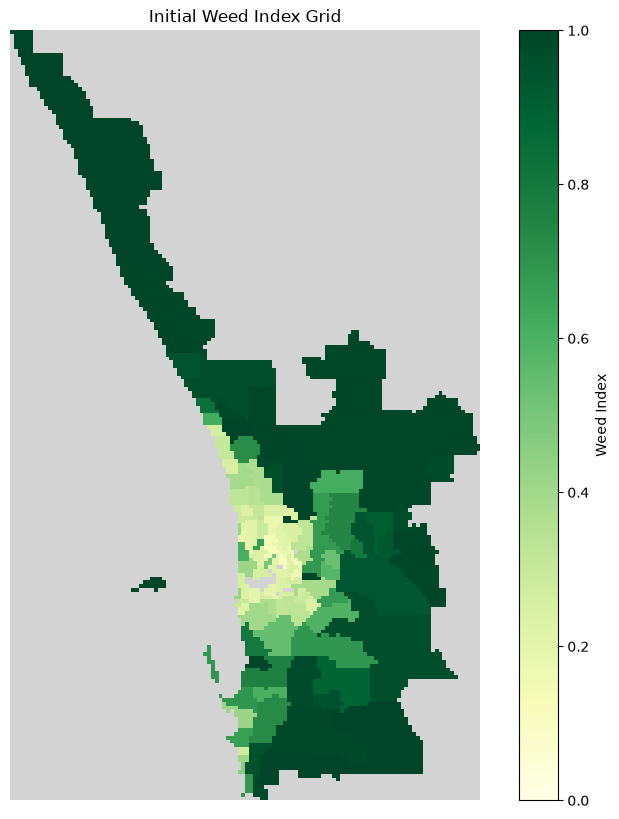

In [6]:
import matplotlib.pyplot as plt

cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

plt.figure(figsize=(10, 10))

plt.imshow(
    weed_grid,
    cmap=cmap,
    vmin=0,
    vmax=1
)

plt.colorbar(label="Weed Index")

plt.title("Initial Weed Index Grid")
plt.axis("off")

plt.show()

# Initialize Cellular Automaton Object

The previously defined spatial preprocessing and simulation components are encapsulated in the WeedCA class. The Cellular Automaton is initialised from the locality polygons using the specified model parameters.

The main model parameters are:

- `pressure_coef`: controls the sensitivity of the initial Weed Index to population density. A larger value results in a faster decrease in the initial Weed Index as population density increases.

- `cell_size`: defines the spatial resolution of the Cellular Automaton grid, in metres.

- `growth_rate`: controls the rate of natural weed growth per timestep.

- `diffusion_rate`: controls the strength of spatial propagation between neighbouring cells.

The model is then initialised using the processed locality polygons and these parameters.

In [7]:
import importlib
import src.weed_ca

importlib.reload(src.weed_ca)

weedca = src.weed_ca.WeedCA.polygon_to_weedca(metro, 
                                                  pressure_coef=0.000783,
                                                  cell_size=1000,
                                                  growth_rate=0.01,
                                                  diffusion_rate=0.01)


# Simulation and Animation

The Cellular Automaton is simulated for a user-defined number of timesteps, with the simulation results visualised as an animation.

The number of timesteps and animation frame rate can be specified through the steps and fps parameters, respectively.

In [8]:

modes = ['growth', 'diffusion']
weedca.animate(frames=100, fps=20, modes=modes)

# Introducing Management Policy Functions

Management policies are implemented as user-defined functions and registered with the WeedCA object. Once a policy function is registered, the Cellular Automaton automatically applies the corresponding removal strategy and calculates the associated management cost during each simulation timestep.

This policy-based design allows different management strategies and cost structures to be evaluated without modifying the underlying Cellular Automaton model.

In [9]:
import numpy as np

def simple_removal(weed_grid, mask):
    # Work on a copy so a policy never changes the simulator input.
    weed_grid = np.where(mask, weed_grid, 0)
    diff = weed_grid * 0.001
    cost = float(np.sum(diff * 200))

    return diff, cost

weedca.register_policy(simple_removal)

In [10]:
modes = ['growth', 'diffusion', 'removal']
weedca.animate(frames=100, fps=20, modes=modes)

# From the simulator to the research question

The simple removal function above illustrates the policy interface. It is **not** Policy A or B and is not a reported experiment. Animation costs are model units, even where the original animation interface displays a dollar sign.

The following cells highlight Steps 01–14 using **sample 2036**, the same case as the report. The Step 08 validation and the report use this same case. Results from other candidates are kept separate.

# 1. Shared experimental settings — Steps 01–04

Every strategy starts from the same landscape. Only the treatment schedule changes. Growth → propagation → removal is the update order. The common budget is a cap, not a guarantee of equal expenditure.

We use the **Step 08 candidate (sample 2036)**, which also passes the block-schedule controls. This is not the largest AB-margin case in the full search.

In [11]:
from dataclasses import replace
import pandas as pd
from IPython.display import display, HTML
from src.weed_experiment import ExperimentConfig, run_experiment
from src.experiment_schedules import (
    PolicyParameters, make_scheduled_policy, repeat_pattern,
    block_schedule, balanced_random_schedule, budget_exhaustion_step,
    ScheduledPolicy, BudgetLimitedPolicy,
)

search = pd.read_csv(repo_root / "results/strong_parrondo_equal_budget_search.csv")
# Use the specific case shown in Step 08; do not select the largest raw AB margin.
selected = search.loc[search["sample_id"].eq(2036)].iloc[0]
config = ExperimentConfig(steps=100, growth_rate=float(selected.growth_rate),
                          diffusion_rate=float(selected.diffusion_rate))
parameters = PolicyParameters(a_rate=float(selected.a_rate), b_rate=float(selected.b_rate),
    max_cells=int(selected.max_cells), boundary=float(selected.boundary),
    b_lower=float(selected.b_lower))
budget = float(selected.budget)
FIGURES = repo_root / "report/sample2036"
DEMO_OUTPUT = repo_root / "results/demonstration"
FIGURES.mkdir(parents=True, exist_ok=True)
DEMO_OUTPUT.mkdir(parents=True, exist_ok=True)
COLORS = {"Baseline": "#666666", "A only": "#d55e00", "B only": "#0072b2", "AB": "#009e73"}
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

def run_schedule(name, schedule, cfg=config, params=parameters, cap=budget):
    # Construct a fresh policy: budgets and schedule positions must not carry over.
    policy = None if schedule is None else make_scheduled_policy(schedule, params, cap)
    return run_experiment(name, metro, cfg, policy)

def summary(results, cap=budget):
    return pd.DataFrame([{
        "Strategy": r.name, "Final mean": r.final_mean,
        "Change (%)": 100 * r.relative_change, "Actual cost": r.final_cost,
        "Budget exhausted at": budget_exhaustion_step(r.cost_history, cap)
            if r.name != "Baseline" else None,
    } for r in results]).set_index("Strategy")

display(pd.Series({"sample_id": int(selected.sample_id), "growth": config.growth_rate,
    "spread": config.diffusion_rate, "A fraction": parameters.a_rate,
    "B fraction": parameters.b_rate, "max cells": parameters.max_cells,
    "boundary": parameters.boundary, "B lower": parameters.b_lower,
    "budget cap": budget}, name="Report settings"))

sample_id       2036.00
growth             0.01
spread             0.01
A fraction         0.15
B fraction         0.65
max cells         50.00
boundary           0.70
B lower            0.45
budget cap    250000.00
Name: Report settings, dtype: float64

## 1.1 Baseline — Step 01

No treatment: this tells us how the model develops without management. We use the regional mean over valid cells; cells outside the study area are excluded.

,Final mean,Change (%),Actual cost,Budget exhausted at
Strategy,,,,
Baseline,0.95818,11.34184,0.0,None


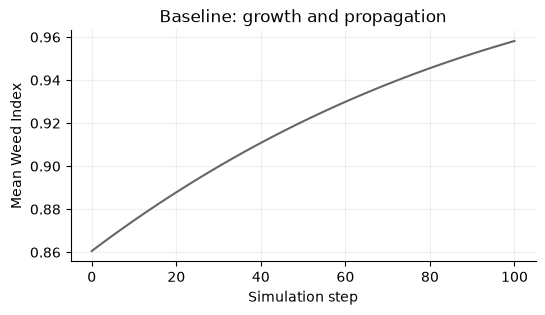

In [12]:
baseline = run_schedule("Baseline", None)
display(summary([baseline]))
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(baseline.mean_weed, color=COLORS["Baseline"])
ax.set(xlabel="Simulation step", ylabel="Mean Weed Index", title="Baseline: growth and propagation")
ax.grid(alpha=.2)
plt.show()

## 1.2 Policy A: treat high-index cells — Step 02

A considers cells with index **at least 0.70**, ranks the highest first, and treats at most **50** cells per call. It removes **15%** of each selected cell's index. These rules are implemented in `HighDensityRemovalPolicy`; the notebook reuses that implementation.

In [13]:
policy_a = parameters.make_policy_a()
print(policy_a)
# A is called at every step, under the shared cumulative budget cap.
a_result = run_schedule("A only", repeat_pattern("A", config.steps))
display(summary([a_result]))

HighDensityRemovalPolicy(threshold=0.7, removal_rate=0.15, max_cells=50, unit_cost=200.0)


,Final mean,Change (%),Actual cost,Budget exhausted at
Strategy,,,,
A only,0.896682,4.195776,149107.484375,None


## 1.3 Policy B: treat possible spread sources — Step 03

B considers **0.45 ≤ index < 0.70**. It ranks candidates by their summed positive differences from their eight neighbours, keeps positive-score candidates, and treats at most **50** cells. It removes **65%** of each selected index.

This is a model rule for prioritising treatment, not a calibrated field-management procedure.

In [14]:
policy_b = parameters.make_policy_b()
print(policy_b)
b_result = run_schedule("B only", repeat_pattern("B", config.steps))
display(summary([b_result]))

SpreadFrontRemovalPolicy(lower_threshold=0.45, upper_threshold=0.7, removal_rate=0.65, max_cells=50, unit_cost=200.0)


,Final mean,Change (%),Actual cost,Budget exhausted at
Strategy,,,,
B only,0.8728,1.420636,199967.171875,None


## 1.4 Alternate AB — Step 04

AB starts with A at step 1, then B at step 2, and repeats. Over 100 steps, each policy is called 50 times. We do **not** add the two removal rules within one step.

In [15]:
ab_schedule = repeat_pattern("AB", config.steps)
print("First 12 calls:", " ".join(ab_schedule[:12]))
ab_result = run_schedule("AB", ab_schedule)
main_results = [baseline, a_result, b_result, ab_result]
display(summary(main_results))

# Verify that the live runs reproduce the report's stored candidate.
for result, prefix in [(a_result, "a"), (b_result, "b"), (ab_result, "ab")]:
    np.testing.assert_allclose(result.relative_change, selected[prefix + "_relative_change"], atol=2e-6, rtol=0)
assert baseline.valid_cell_count == 6933
summary(main_results).to_csv(DEMO_OUTPUT / "main_summary.csv")
summary(main_results).to_csv(FIGURES / "summary.csv")

First 12 calls: A B A B A B A B A B A B


,Final mean,Change (%),Actual cost,Budget exhausted at
Strategy,,,,
Baseline,0.958180,11.341840,0.000000,None
A only,0.896682,4.195776,149107.484375,None
B only,0.872800,1.420636,199967.171875,None
AB,0.858799,-0.206371,228212.656250,None


## 1.5 The report figure: trajectories and actual expenditure

This is **Figure A2 in the report**, generated from the same live results. All treated strategies remain below the common cap at 100 steps. Their actual spending differs, with AB spending more than A or B. The dashed initial-mean line marks the reversal boundary; Baseline is the untreated comparison.

This is already a **Parrondo-type reversal at step 100**: A and B finish above the initial mean, while AB finishes below it. The criterion concerns the final state, not whether A and B increase at every intermediate step. Baseline is context and does not enter the sign test.

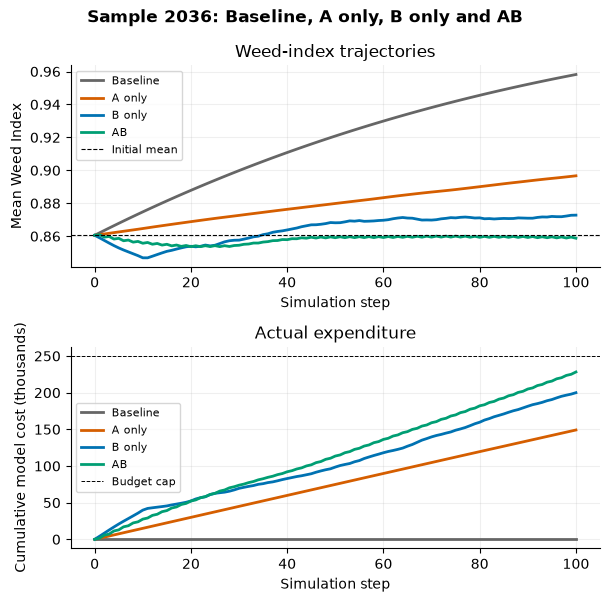

In [16]:
trajectories = pd.DataFrame({"step": range(config.steps + 1),
    **{r.name: r.mean_weed for r in main_results}})
costs = pd.DataFrame({"step": range(config.steps + 1),
    **{r.name: r.cost_history for r in main_results}})
trajectories.to_csv(FIGURES / "trajectories.csv", index=False)
costs.to_csv(FIGURES / "costs.csv", index=False)
fig, axes = plt.subplots(2, 1, figsize=(6.2, 6.1))
for r in main_results:
    axes[0].plot(r.mean_weed, label=r.name, color=COLORS[r.name], lw=2)
    axes[1].plot(r.cost_history / 1000, label=r.name, color=COLORS[r.name], lw=2)
axes[0].axhline(baseline.initial_mean, color="black", ls="--", lw=.8, label="Initial mean")
axes[0].set(xlabel="Simulation step", ylabel="Mean Weed Index", title="Weed-index trajectories")
axes[1].axhline(budget / 1000, color="black", ls="--", lw=.7, label="Budget cap")
axes[1].set(xlabel="Simulation step", ylabel="Cumulative model cost (thousands)", title="Actual expenditure")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.suptitle(f"Sample {int(selected.sample_id)}: Baseline, A only, B only and AB", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "four_strategies.png", dpi=200, bbox_inches="tight")
plt.show()

## 1.6 Parrondo-type reversal: the final-state comparison

The same runs are shown as final changes at **T = 100**. Above zero means increased infestation (losing); below zero means decreased infestation (winning). A and B lose separately while AB wins. Baseline is shown for context only.

This plot uses the actual simulation results above, not invented schematic values. It does not imply that AB performs best at every time or on every outcome measure.

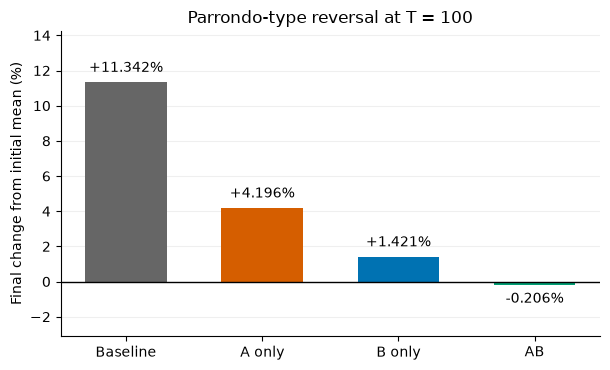

A > 0, B > 0, AB < 0: True; margin = 0.206 percentage points


In [17]:
# Read the final values from the existing results; do not rerun simulations.
final_changes = np.array([100 * r.relative_change for r in main_results])
reversal = (a_result.relative_change > 0 and b_result.relative_change > 0
            and ab_result.relative_change < 0)
margin_pp = 100 * min(a_result.relative_change, b_result.relative_change,
                      -ab_result.relative_change)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
bars = ax.bar([r.name for r in main_results], final_changes,
              color=[COLORS[r.name] for r in main_results], width=.6)
ax.axhline(0, color="black", lw=1)
for bar, value in zip(bars, final_changes):
    ax.annotate(f"{value:+.3f}%", (bar.get_x()+bar.get_width()/2, value),
                xytext=(0, 5 if value >= 0 else -5), textcoords="offset points",
                ha="center", va="bottom" if value >= 0 else "top")
ax.set(ylabel="Final change from initial mean (%)",
       title=f"Parrondo-type reversal at T = {config.steps}" if reversal
             else f"No Parrondo-type reversal at T = {config.steps}")
ax.margins(y=.25)
ax.grid(axis="y", alpha=.2)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(DEMO_OUTPUT / "parrondo_final_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"A > 0, B > 0, AB < 0: {reversal}; margin = {margin_pp:.3f} percentage points")

# 2. What counts as a reversal? — Steps 05–06

For strategy $s$, $\Delta_s=(\overline W_s(T)-\overline W(0))/\overline W(0)$.
A reversal requires **A > 0, B > 0, AB < 0**. Its margin is $M_{AB}=\min(\Delta_A,\Delta_B,-\Delta_{AB})$. Positive margin means all three conditions hold; it is not a confidence interval.

Figure A1 below illustrates a simple additive expectation and a reversal. **These straight lines are invented examples, not simulation outputs.**

AB margin: 0.206 percentage points


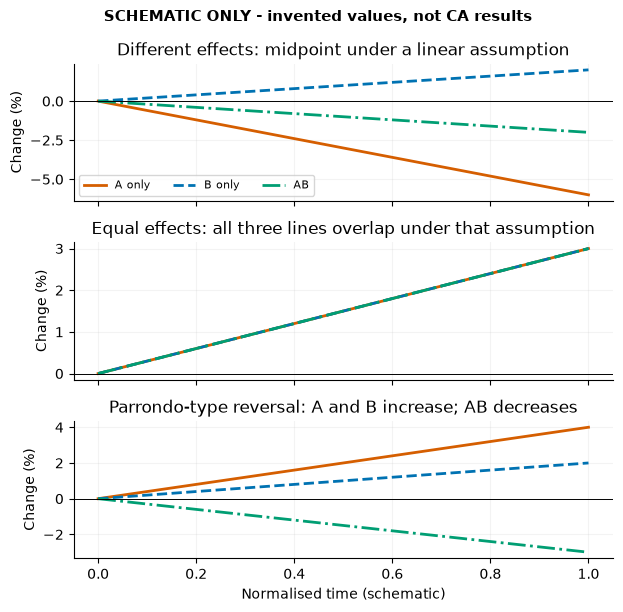

In [18]:
margin = min(a_result.relative_change, b_result.relative_change, -ab_result.relative_change)
print(f"AB margin: {100 * margin:.3f} percentage points")
assert margin > 0

fig, axes = plt.subplots(3, 1, figsize=(6.2, 6.2), sharex=True)
x = np.linspace(0, 1, 101)
examples = [(-6, 2, -2), (3, 3, 3), (4, 2, -3)]
titles = ["Different effects: midpoint under a linear assumption",
          "Equal effects: all three lines overlap under that assumption",
          "Parrondo-type reversal: A and B increase; AB decreases"]
for ax, ends, title in zip(axes, examples, titles):
    for name, end, style in zip(["A only", "B only", "AB"], ends, ["-", "--", "-."]):
        ax.plot(x, x * end, label=name, color=COLORS[name], ls=style, lw=2)
    ax.axhline(0, color="black", lw=.7)
    ax.set(title=title, ylabel="Change (%)")
    ax.grid(alpha=.15)
axes[0].legend(fontsize=8, ncol=3, loc="lower left")
axes[-1].set_xlabel("Normalised time (schematic)")
fig.suptitle("SCHEMATIC ONLY - invented values, not CA results", fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "schematic.png", dpi=200, bbox_inches="tight")
plt.show()

# 3. Parameter search — Steps 05–09

We inspect the saved **2,400 tested combinations**, recompute the AB sign criterion, and show the represented parameter levels. This is not the full Cartesian product. The original search script and sampling seed have not been recovered; the CSV preserves the tested combinations. Loading it is not a new simulation run.

In [19]:
parameter_columns = ["a_rate", "b_rate", "max_cells", "boundary", "b_lower",
                     "growth_rate", "diffusion_rate", "budget"]
search["AB reversal"] = ((search.a_relative_change > 0) &
    (search.b_relative_change > 0) & (search.ab_relative_change < 0))
search["computed_margin"] = np.minimum.reduce([
    search.a_relative_change, search.b_relative_change, -search.ab_relative_change])
np.testing.assert_allclose(search.computed_margin, search.ab_margin, atol=2e-6)
print(f"AB reversals: {int(search['AB reversal'].sum())} / {len(search)}")
display(pd.DataFrame([{"Parameter": p, "Tested levels": ", ".join(f"{v:g}" for v in sorted(search[p].unique()))}
    for p in parameter_columns]).set_index("Parameter"))
display(search.sort_values("computed_margin", ascending=False)[
    ["sample_id", *parameter_columns, "computed_margin"]].head(5))

AB reversals: 52 / 2400


,Tested levels
Parameter,
a_rate,"0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0...."
b_rate,"0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0...."
max_cells,"25, 50, 75, 100, 150, 200, 300"
boundary,"0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9"
b_lower,"0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0...."
growth_rate,"0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04"
diffusion_rate,"0.0025, 0.005, 0.01, 0.015, 0.02, 0.03"
budget,"150000, 200000, 250000, 300000, 350000, 400000..."


,sample_id,a_rate,b_rate,max_cells,boundary,b_lower,growth_rate,diffusion_rate,budget,computed_margin
0,256,0.25,0.50,150,0.55,0.25,0.020,0.0100,450000,0.024480
1,466,0.30,0.80,100,0.65,0.25,0.035,0.0050,450000,0.022643
2,972,0.30,0.45,100,0.55,0.05,0.015,0.0100,350000,0.021394
3,277,0.35,0.45,100,0.60,0.15,0.020,0.0025,350000,0.020427
5,1900,0.30,0.80,100,0.60,0.20,0.020,0.0025,350000,0.019751


## 3.1 Which settings are associated with reversals?

Each point is the percentage of stored combinations at that parameter level that pass the **AB** sign test. Other parameters are mixed together, so these plots show associations, not isolated causal importance. Counts are exported alongside rates.

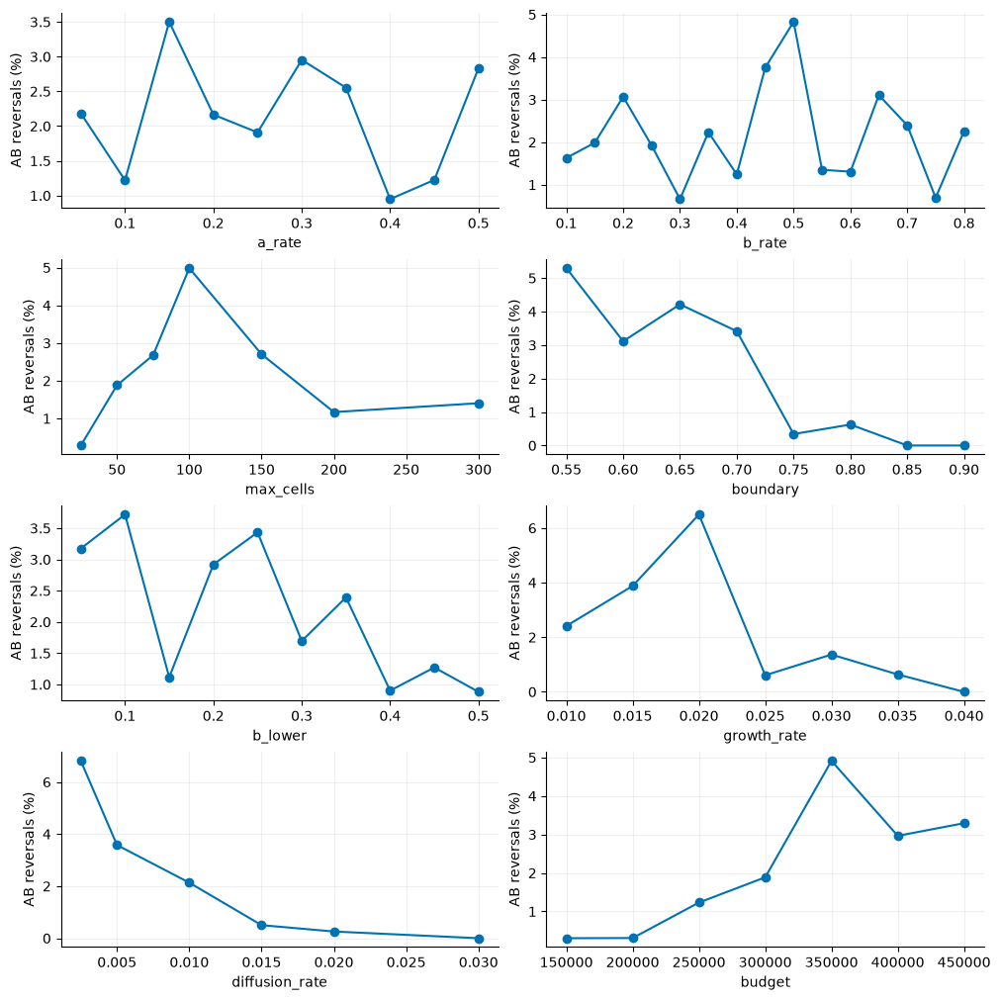

,Parameter,Marginal range (percentage points)
6,diffusion_rate,6.811989
5,growth_rate,6.493506
3,boundary,5.298013
2,max_cells,4.702863
7,budget,4.609343
1,b_rate,4.165335
4,b_lower,2.837951
0,a_rate,2.554078


In [20]:
sensitivity = {}
fig, axes = plt.subplots(4, 2, figsize=(10, 10), constrained_layout=True)
for ax, p in zip(axes.flat, parameter_columns):
    table = search.groupby(p)["AB reversal"].agg(["size", "sum", "mean"])
    table["percent"] = 100 * table["mean"]
    sensitivity[p] = table
    table.to_csv(DEMO_OUTPUT / f"sensitivity_{p}.csv")
    ax.plot(table.index, table.percent, marker="o", color="#0072b2")
    ax.set(xlabel=p, ylabel="AB reversals (%)")
    ax.grid(alpha=.2)
fig.savefig(DEMO_OUTPUT / "parameter_associations.png", dpi=160, bbox_inches="tight")
plt.show()
ranking = pd.DataFrame([{"Parameter": p, "Marginal range (percentage points)":
    t.percent.max() - t.percent.min()} for p, t in sensitivity.items()])
display(ranking.sort_values("Marginal range (percentage points)", ascending=False))

## 3.2 A small live follow-up search

Hold the selected policy and budget fixed, and vary only growth and propagation. Each grid point reruns **A, B and AB** from the common initial landscape. This checks local sensitivity around sample 2036; it is not a new global optimum search.

,growth,spread,A (%),B (%),AB (%),margin (pp)
0,0.008,0.008,1.124,0.904,-2.222,0.904
1,0.008,0.010,2.465,1.071,-1.114,1.071
2,0.008,0.012,3.692,1.365,0.081,-0.081
3,0.010,0.008,3.016,0.989,-1.397,0.989
4,0.010,0.010,4.196,1.421,-0.206,0.206
5,0.010,0.012,5.271,1.885,0.805,-0.805
6,0.012,0.008,4.679,1.427,-0.395,0.395
7,0.012,0.010,5.706,2.101,0.546,-0.546
8,0.012,0.012,6.644,2.567,1.584,-1.584


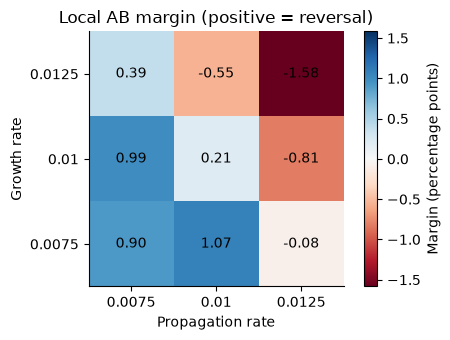

In [21]:
local_rows = []
for growth in [0.0075, 0.0100, 0.0125]:
    for spread in [0.0075, 0.0100, 0.0125]:
        cfg = replace(config, growth_rate=growth, diffusion_rate=spread)
        runs = [run_schedule(name, repeat_pattern(pattern, cfg.steps), cfg=cfg)
                for name, pattern in [("A only", "A"), ("B only", "B"), ("AB", "AB")]]
        da, db, dab = [r.relative_change for r in runs]
        local_rows.append({"growth": growth, "spread": spread, "A (%)": da*100,
            "B (%)": db*100, "AB (%)": dab*100, "margin (pp)": min(da, db, -dab)*100})
local_search = pd.DataFrame(local_rows)
local_search.to_csv(DEMO_OUTPUT / "local_search.csv", index=False)
display(local_search.round(3))
pivot = local_search.pivot(index="growth", columns="spread", values="margin (pp)")
fig, ax = plt.subplots(figsize=(5, 3.5))
limit = max(abs(pivot.to_numpy()).max(), .01)
im = ax.imshow(pivot, origin="lower", cmap="RdBu", vmin=-limit, vmax=limit)
ax.set(xticks=range(3), xticklabels=pivot.columns, yticks=range(3), yticklabels=pivot.index,
       xlabel="Propagation rate", ylabel="Growth rate", title="Local AB margin (positive = reversal)")
for i in range(3):
    for j in range(3): ax.text(j, i, f"{pivot.iloc[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Margin (percentage points)")
fig.tight_layout()
fig.savefig(DEMO_OUTPUT / "local_margin.png", dpi=160, bbox_inches="tight")
plt.show()

# 4. Beyond the report: BA and A50B50 — Steps 07–08

BA starts with B and alternates. A50B50 instead applies A for steps 1–50 and B for steps 51–100. B50A50 is included as a symmetry check. All four schedules have 50 calls of each policy and the same budget cap, but their actual expenditure and treatment timing can differ.

These are **additional controls at the report candidate**, not results from a different finalist.

,Final mean,Change (%),Actual cost,Budget exhausted at
Strategy,,,,
A only,0.896682,4.195776,149107.484375,None
B only,0.872800,1.420636,199967.171875,None
AB,0.858799,-0.206371,228212.656250,None
BA,0.857575,-0.348586,229166.359375,None
A50B50,0.901066,4.705131,138087.875000,None
B50A50,0.886328,2.992573,173466.421875,None


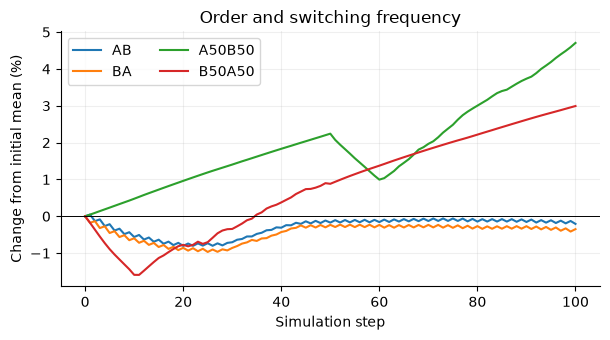

In [22]:
extra_schedules = {"BA": repeat_pattern("BA", 100),
                   "A50B50": block_schedule("A", 100),
                   "B50A50": block_schedule("B", 100)}
extra_results = [run_schedule(name, schedule) for name, schedule in extra_schedules.items()]
for schedule in extra_schedules.values():
    assert schedule.count("A") == schedule.count("B") == 50
display(summary([a_result, b_result, ab_result, *extra_results]))
summary(extra_results).to_csv(DEMO_OUTPUT / "schedule_controls.csv")
fig, ax = plt.subplots(figsize=(6.2, 3.5))
for r in [ab_result, *extra_results]:
    ax.plot(100 * (r.mean_weed/r.initial_mean - 1), label=r.name)
ax.axhline(0, color="black", lw=.7)
ax.set(xlabel="Simulation step", ylabel="Change from initial mean (%)", title="Order and switching frequency")
ax.legend(ncol=2)
ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(DEMO_OUTPUT / "schedule_controls.png", dpi=160, bbox_inches="tight")
plt.show()

## 4.1 Random policy order — Step 10

Shuffle exactly 50 A and 50 B calls using seeds 0–99. The policy rules remain unchanged. This asks whether strict alternation is necessary for a negative final change at this candidate. It does not establish the probability over all possible schedules. Step 08 recorded 46 negative final changes among these 100 seeds; a later 200-seed extension recorded 105/200, so periodic alternation is not uniquely successful.

Negative final changes: 46 / 100


,Change (%),Actual cost
count,100.000000,100.000000
mean,-0.042081,225628.361719
std,0.381917,7577.691303
min,-1.104000,209800.687500
25%,-0.248945,218951.054688
50%,0.017714,225343.945312
75%,0.155925,231684.820312
max,0.717916,242423.953125


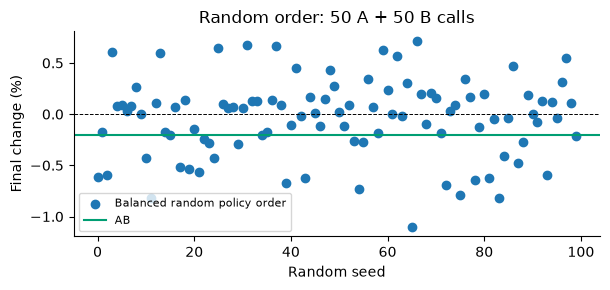

In [23]:
random_results = [run_schedule(f"Random order {seed}", balanced_random_schedule(100, seed))
                  for seed in range(100)]
random_summary = summary(random_results)
random_summary.to_csv(DEMO_OUTPUT / "random_order.csv")
print("Negative final changes:", int((random_summary["Change (%)"] < 0).sum()), "/ 100")
display(random_summary[["Change (%)", "Actual cost"]].describe())
fig, ax = plt.subplots(figsize=(6.2, 3))
ax.scatter(range(100), random_summary["Change (%)"], label="Balanced random policy order")
ax.axhline(100 * ab_result.relative_change, color=COLORS["AB"], label="AB")
ax.axhline(0, color="black", ls="--", lw=.7)
ax.set(xlabel="Random seed", ylabel="Final change (%)", title="Random order: 50 A + 50 B calls")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DEMO_OUTPUT / "random_order.png", dpi=160, bbox_inches="tight")
plt.show()

# 5. A brief mechanism check — Steps 11–14

Did A directly hand treated cells to B? We observe A's actual removal and ask whether it moves those cells into B's eligibility band. We also probe B's selected targets immediately before and after A, holding ecological updates fixed. The next B call follows another growth/propagation update, so these are separate checks.

Zero recorded handoffs rules out this immediate explanation **for the tested case**; it does not rule out every indirect spatial interaction.

In [24]:
class HandoffObserver:
    def __init__(self):
        self.inner = make_scheduled_policy(ab_schedule, parameters, budget)
        self.probe = parameters.make_policy_b()
        self.reset()

    def reset(self):
        self.inner.reset()
        self.index = 0
        self.events = []
        self.handoff = None

    def __call__(self, grid, mask):
        removal, cost = self.inner(grid, mask)
        if self.index % 2 == 0:
            after = grid - removal
            before_band = mask & (grid >= parameters.b_lower) & (grid < parameters.boundary)
            after_band = mask & (after >= parameters.b_lower) & (after < parameters.boundary)
            self.handoff = (removal > 0) & ~before_band & after_band
            self.events.append({"A step": self.index + 1,
                "A treated": int((removal > 0).sum()),
                "A-to-B band entries": int(self.handoff.sum()),
                "Changed immediate B targets": int(((self.probe(grid, mask)[0] > 0) ^
                    (self.probe(after, mask)[0] > 0)).sum()),
                "Next B treats handoff": 0})
        else:
            self.events[-1]["Next B treats handoff"] = int(((removal > 0) & self.handoff).sum())
        self.index += 1
        return removal, cost

observer = HandoffObserver()
observed_ab = run_experiment("Observed AB", metro, config, observer)
np.testing.assert_allclose(observed_ab.mean_weed, ab_result.mean_weed, atol=1e-7)
events = pd.DataFrame(observer.events)
events.to_csv(DEMO_OUTPUT / "handoff_events.csv", index=False)
display(events.drop(columns="A step").sum().rename("Total across A calls"))

A treated                      2500
A-to-B band entries               0
Changed immediate B targets       0
Next B treats handoff             0
Name: Total across A calls, dtype: int64

## 5.1 Random B targets are a different question — Step 13

Keep the AB order but randomise B's ranking within the same positive-score eligibility set. This is **not random policy order**. Three seeds (0–2), matching the saved Step 13 check, test whether the original spread-score ranking is necessary for AB to decrease at this candidate.

In [25]:
class RandomBRanking:
    def __init__(self, seed):
        self.rng = np.random.default_rng(seed)

    def __call__(self, grid, mask):
        # Use the existing B implementation with a very large capacity to obtain
        # its complete positive-score eligibility set without duplicating scoring.
        eligibility_probe = replace(parameters, max_cells=int(mask.sum())).make_policy_b()
        eligible = np.flatnonzero(eligibility_probe(grid, mask)[0] > 0)
        chosen = self.rng.permutation(eligible)[:parameters.max_cells]
        removal = np.zeros_like(grid, dtype=np.float32)
        removal.ravel()[chosen] = grid.ravel()[chosen] * parameters.b_rate
        return removal, float(removal.sum() * parameters.unit_cost)

random_b_results = []
for seed in range(3):
    scheduled = ScheduledPolicy(ab_schedule, parameters)
    scheduled.policy_b = RandomBRanking(seed)
    result = run_experiment(f"Random B ranking {seed}", metro, config,
                            BudgetLimitedPolicy(scheduled, budget))
    random_b_results.append(result)
ranking_summary = summary(random_b_results)
ranking_summary.to_csv(DEMO_OUTPUT / "random_b_ranking.csv")
print("AB decreases with random B ranking:", int((ranking_summary["Change (%)"] < 0).sum()), "/ 3")
display(ranking_summary[["Change (%)", "Actual cost"]].describe())

AB decreases with random B ranking: 0 / 3


,Change (%),Actual cost
count,3.000000,3.000000
mean,1.553426,244960.223958
std,0.061442,543.493939
min,1.486032,244391.515625
25%,1.526976,244703.140625
50%,1.567920,245014.765625
75%,1.587123,245244.578125
max,1.606326,245474.390625


## 5.2 Timing, resources and horizon — Steps 10, 12, 14

Three short checks reproduce the report's limitations. Removing propagation changes the ecological process. A lower cap makes actual expenditure equal across treated strategies. Extending the horizon to 156 steps with a proportional cap tests whether the reversal persists. The matched cap is 90% of the smallest original expenditure across the six deterministic schedules, approximately 124,279 units, matching Step 14. These interventions change multiple feedbacks and do not isolate one complete cause.

In [26]:
checks = []
matched_cap = .9 * min(r.final_cost for r in [a_result, b_result, ab_result, *extra_results])
for setting, cfg, cap in [
    ("No propagation", replace(config, diffusion_rate=0), budget),
    ("Matched lower expenditure", config, matched_cap),
    ("156 steps, proportional cap", replace(config, steps=156), budget*156/100),
]:
    for name, pattern in [("A only", "A"), ("B only", "B"), ("AB", "AB")]:
        r = run_schedule(name, repeat_pattern(pattern, cfg.steps), cfg=cfg, cap=cap)
        checks.append({"Setting": setting, "Strategy": name,
            "Change (%)": 100*r.relative_change, "Actual cost": r.final_cost,
            "Budget exhausted at": budget_exhaustion_step(r.cost_history, cap)})
        if setting == "Matched lower expenditure":
            assert abs(r.final_cost-cap) < .02
checks = pd.DataFrame(checks)
checks.to_csv(DEMO_OUTPUT / "mechanism_controls.csv", index=False)
display(checks.pivot(index="Setting", columns="Strategy", values="Change (%)").round(3))
display(summary([a_result, b_result, ab_result]))

Strategy,A only,AB,B only
Setting,,,
"156 steps, proportional cap",6.362,0.389,2.285
Matched lower expenditure,6.046,6.460,6.340
No propagation,-1.421,-2.998,-0.068


,Final mean,Change (%),Actual cost,Budget exhausted at
Strategy,,,,
A only,0.896682,4.195776,149107.484375,None
B only,0.872800,1.420636,199967.171875,None
AB,0.858799,-0.206371,228212.656250,None


# 6. Conclusions and report connection

At sample 2036, A and B alone increase the final mean, while AB decreases it. The result depends on the tested settings, resources and horizon. Compare the live BA, block and random-order outputs before claiming that strict alternation is uniquely effective.

No immediate A-to-B handoff was recorded. None of the three main treated strategies exhausts the original cap at 100 steps, so budget exhaustion does not explain this case. AB spends more and removes more than A or B. Replacing B's spread-score ranking with random ranking makes AB increase in the three saved runs. These checks suggest that treatment order and spatial targeting matter, but do not isolate one complete mechanism or demonstrate better cost efficiency.

**Report assets:** `report/sample2036/schematic.png` (A1) and `four_strategies.png` (A2) are generated above. The report already includes these files directly. Additional demonstration figures and tables are in `results/demonstration/`. The demonstration extends the report with schedule controls; these extra controls are not currently report figures.

**Sources:** [Brown & Brooks, Bushland Weeds](https://www.dbca.wa.gov.au/media/1822/download), [Harmer & Abbott (1999)](https://doi.org/10.1038/47220), [Landgate localities](https://catalogue.data.wa.gov.au/dataset/localities), [ABS 2021 Census datapacks](https://www.abs.gov.au/census/find-census-data/datapacks). Population-based initialisation is a modelling assumption, not a fit to observed weeds.

**AI assistance:** Core code and the initial direction/content were prepared by the authors. GPT-5.6 (OpenAI) assisted with debugging, refinement and writing; Codex assisted with notebook consolidation, execution checks and figure export. The authors are responsible for understanding, checking and explaining the submitted work.